# ANN, SVM, & Complexity
### Jimmy Azar

## Artificial Neural Networks

We'll build and test a multilayer perceptron.

First, we load the data from the file 'boomerang2D.txt' and split the dataset randomly into a training set and a test set of around equal size. Then, we build a feed-forward neural network with two hidden layers consisting of 30 units each. Predictions are done over the test set. We also visualize the decision boundary of the neural network classifier.

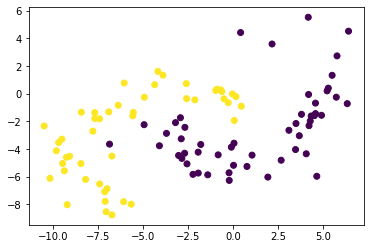

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

path_to_file = '../data/boomerang2D.txt'
data = pd.read_csv(path_to_file, sep=' ')

X = data.drop('label', axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

plt.scatter(X_train['f1'], X_train['f2'], c=y_train)
plt.show() 

In [2]:
from sklearn.neural_network import MLPClassifier 
import warnings
warnings.filterwarnings('ignore')

# default activation is 'relu' for hidden layers.
model = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(30,30), activation='logistic')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)         

model.score(X_test, y_test)  # accuracy
n_error = (y_pred!=y_test).sum()

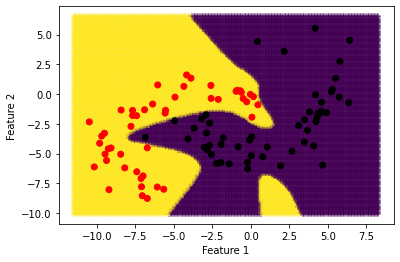

In [3]:
# decision boundary 
step = 0.1
x_min, x_max = X.iloc[:,0].min() - 1, X.iloc[:,0].max() + 1
y_min, y_max = X.iloc[:,1].min() - 1, X.iloc[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max,step), np.arange(y_min, y_max,step))

labels_pred = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = labels_pred.reshape(xx.shape)

plt.scatter(xx.ravel(), yy.ravel(), c=labels_pred, marker='+', alpha=0.4) 
plt.scatter(X_train.iloc[:,0], X_train.iloc[:,1], c=y_train.replace({1:'black',2:'red'}))
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

Finally, we plot the ROC curve as measured on the test set and compute the area under the curve (AUC).

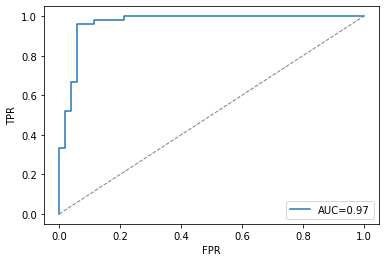

In [4]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true=y_test, y_score=y_pred_prob[:,0], pos_label=1)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC={roc_auc.round(2)}')
plt.plot([0, 1], [0, 1], c='gray', lw=1, linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend(loc="lower right")
plt.show()

## Classifier Complexity

Next, we'll construct learning curves. We load the data from the file 'boomerang2Dlarge.txt' which consists of a dataset with labels for two classes. From this dataset, we create training sets of size $n = [10,20,50,100]$ in a stratified manner with regard to class labels. We also create these training sets randomly 10 times for each training set size. In each iteration, we train a quadratic classifier and use the remaining test set to obtain the number of misclassified test objects. Finally, we generate an errorbar plot using the mean and standard deviation of the classification error rate.

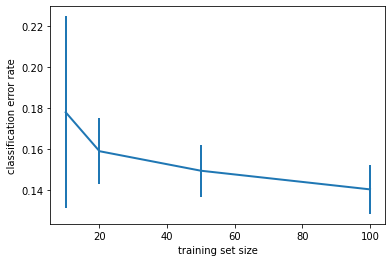

In [5]:
path_to_file = '../data/boomerang2Dlarge.txt'
data = pd.read_csv(path_to_file, sep=' ')

X = data.drop(['label'], axis=1)
y = data['label']

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as qda  
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as lda  

n_train = [10, 20, 50, 100]
error_test_mean, error_test_std = [], []
for n in n_train:
    error_test = []
    for i in range(10):
        X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=n, stratify=y)
        model = qda().fit(X_train, y_train) # can change this to lda() for a linear classifier  
        error_test.append(1 - model.score(X_test, y_test))
    
    error_test_mean.append(np.mean(error_test))
    error_test_std.append(np.std(error_test))

plt.errorbar(n_train, error_test_mean, error_test_std, lw=2)
plt.xlabel('training set size')
plt.ylabel('classification error rate')
plt.show()

## Support Vector Machine

We'll explore the support vector classifier using different kernel types.

Using the same dataset as before, we split the dataset in a stratified manner into a training set and a test set of equal size. We then train and test a support vector classifier. 

We test the classifier using the test set and generate a confusion matrix. We choose a radial basis function kernel `kernel='rbf'` with `C=1` and `gamma=1`, and we report the classification error. Finally, we visualize the decision boundary of the classifier.

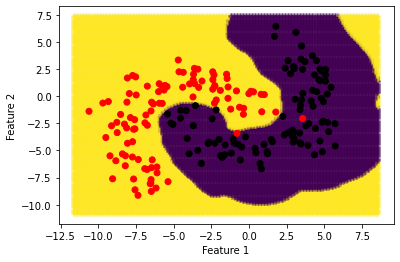

In [6]:
path_to_file = '../data/boomerang2Dlarge.txt'
data = pd.read_csv(path_to_file, sep=' ')

X = data.drop(['label'],axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, stratify=y)

y_train.value_counts()

from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

model = SVC(kernel='rbf', C=1, gamma=1, probability=True).fit(X_train, y_train)

y_pred = model.predict(X_test) 
model.predict_proba(X)
model.score(X_test, y_test)
confusion_matrix(y_true=y_test, y_pred=y_pred)

# decision boundary 
step = 0.1
x_min, x_max = X.iloc[:,0].min() - 1, X.iloc[:,0].max() + 1
y_min, y_max = X.iloc[:,1].min() - 1, X.iloc[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min,x_max,step), np.arange(y_min,y_max,step))

labels_pred = model.predict(np.c_[xx.ravel(), yy.ravel()]) #or np.stack(...,
Z = labels_pred.reshape(xx.shape)

plt.scatter(xx.ravel(), yy.ravel(), c=labels_pred, marker='+', alpha=0.4) 
plt.scatter(X_train.iloc[:,0], X_train.iloc[:,1], c=y_train.replace({1:'black',2:'red'})) #plot this last
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## Support Vector Regression

We'll explore support vector regression. First, we generate 50 noisy data points with $\sigma=0.1$ (standard deviation of the Gaussian noise added). We plot the resulting data points. Then, we train a support vector machine to perform regression with default parameters.

We predict the response at the same data points using the trained model. Then, we add the predicted points to the previous plot using a different color and marker. Finally, we compute the root-mean-square-error (RMSE) between the predicted values and the true values.

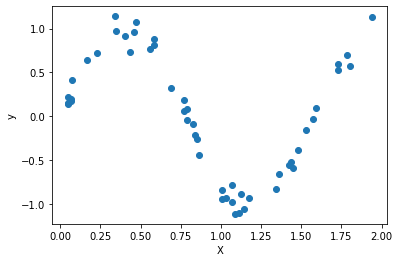

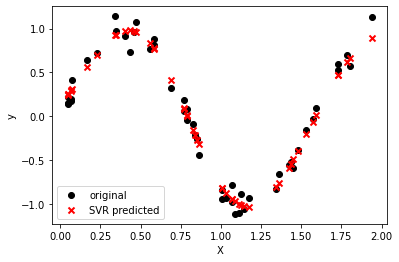

In [7]:
def synth_data(n_samples, sigma):
    X = np.random.uniform(low=0,high=2,size=n_samples)
    X = np.sort(X)
    y = np.sin(4*X) + np.random.normal(loc=0,scale=sigma,size=n_samples) 
    return X, y

X_train, y_train = synth_data(n_samples=50, sigma=0.1)

plt.scatter(X_train, y_train)
plt.xlabel('X')
plt.ylabel('y')
plt.show()

from sklearn.svm import SVR
model = SVR(kernel='rbf', C=1, epsilon=0.1, gamma='scale').fit(X_train.reshape(-1,1), y_train)
y_pred = model.predict(X_train.reshape(-1,1))

plt.scatter(X_train, y_train, c='black', label='original')
plt.scatter(X_train, y_pred, c='red', marker='x', lw=2, label='SVR predicted')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show() 

rmse = np.sqrt(((y_train - y_pred)**2).mean())

To find the optimal hyperparameters to use, we perform a grid search for `gamma = np.linspace(1,10,20)`, `epsilon = np.linspace(0,1,10)`, and cost `C = 2**np.arange(10)`.

In [8]:
from sklearn.model_selection import GridSearchCV

parameters = {'kernel' : ['rbf'], 
              'gamma'  : np.linspace(1,10,20),
              'epsilon': np.linspace(0,1,10),
              'C'      : 2**np.arange(2,10)}

# neg_mean_squared_error is used because the method selects max criterion by default
model = GridSearchCV(SVR(), parameters, scoring='neg_mean_squared_error', cv=5) 
model.fit(X_train.reshape(-1,1), y_train)
model.best_params_

y_pred = model.predict(X_train.reshape(-1,1))

Using the optimized model, we perform prediction that includes extrapolation, i.e. predicting the response for input that extends beyond the range of the training set.

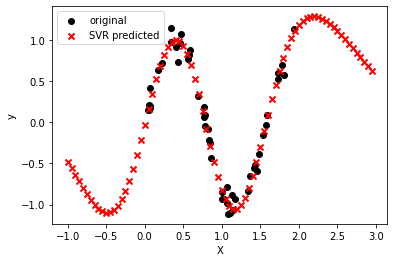

In [9]:
X_test = np.arange(-1,3,0.05)
y_pred = model.predict(X_test.reshape(-1,1))

plt.scatter(X_train, y_train, c='black', label='original')
plt.scatter(X_test, y_pred, c='red', marker='x', lw=2, label='SVR predicted')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show() 